In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
pd.set_option("display.max_columns",None)

In [25]:
sns.set_style("whitegrid")

In [26]:
df=pd.read_csv("german_credit_data.csv")

In [27]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [28]:
df['Age'].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

In [29]:
df.duplicated().sum()

0

In [30]:
df.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [31]:
df=df.dropna().reset_index(drop=True)

In [44]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [46]:
df.drop(columns='Unnamed: 0',inplace=True)

In [48]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

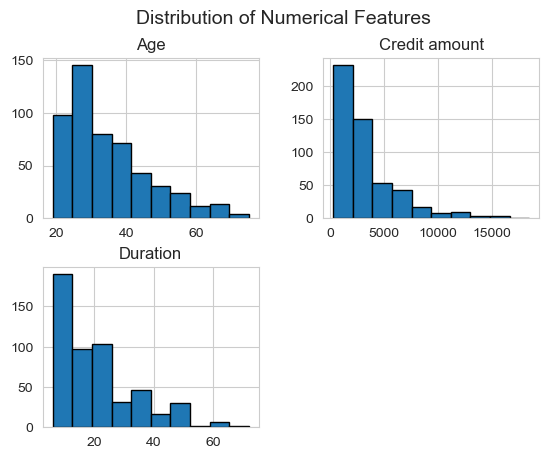

In [56]:
df[['Age','Credit amount','Duration']].hist(bins=10,edgecolor="black")
plt.suptitle("Distribution of Numerical Features",fontsize=14)
plt.show()

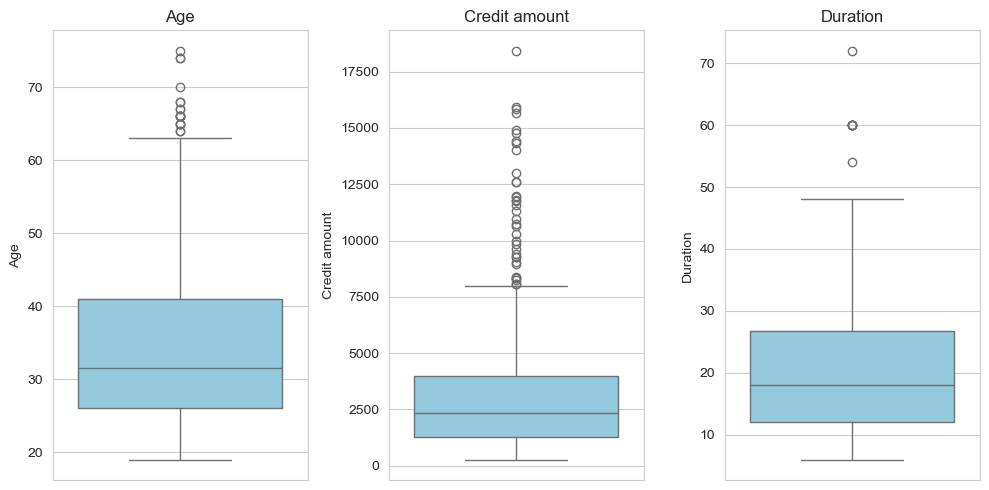

In [60]:
plt.figure(figsize=(10,5))
for i , col in enumerate (["Age","Credit amount", "Duration"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(col)

plt.tight_layout()
plt.show()
    

In [66]:
df.query("Duration >= 60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [80]:
categorical_cols=["Sex","Job","Housing","Saving accounts", "Checking account", "Purpose"]



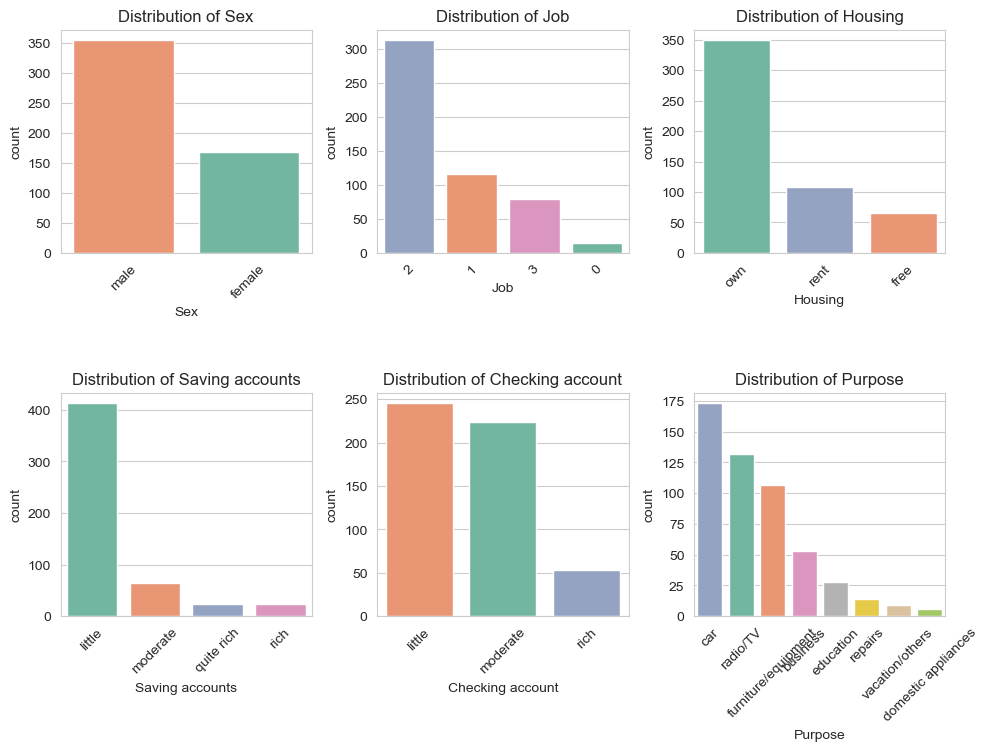

In [90]:
plt.figure(figsize=(10,10))
for i, col in enumerate(categorical_cols):
    plt.subplot(3,3,i+1)
    sns.countplot( data=df,x=col, hue=col, palette="Set2", legend=False, order=df[col].value_counts().index )   
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [92]:
corr= df[["Age","Job","Credit amount","Duration"]].corr()

In [94]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


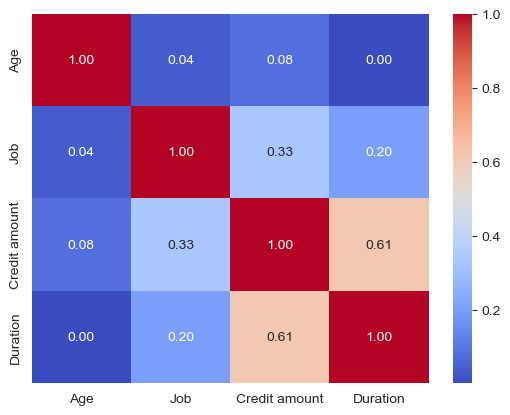

In [96]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [98]:
df.groupby('Job')["Credit amount"].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [100]:
df.groupby("Sex")["Credit amount"].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [102]:
pd.pivot_table(df, values="Credit amount", index="Housing", columns="Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


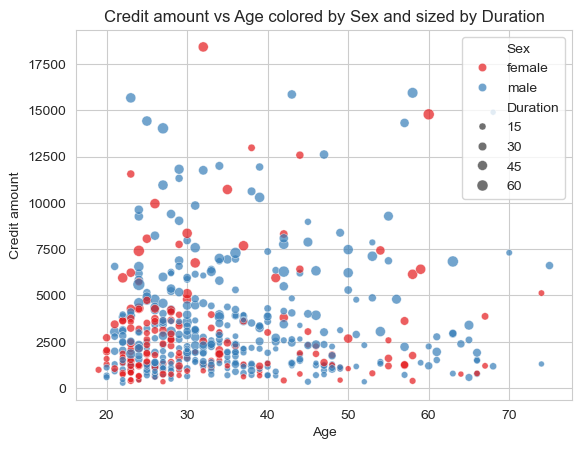

In [106]:
sns.scatterplot(data=df ,x="Age", y="Credit amount", hue="Sex", size="Duration", alpha=0.7, palette="Set1")
plt.title("Credit amount vs Age colored by Sex and sized by Duration")
plt.show()

C:\Users\leela\AppData\Local\Temp\ipykernel_13112\3936670938.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette="Pastel1")


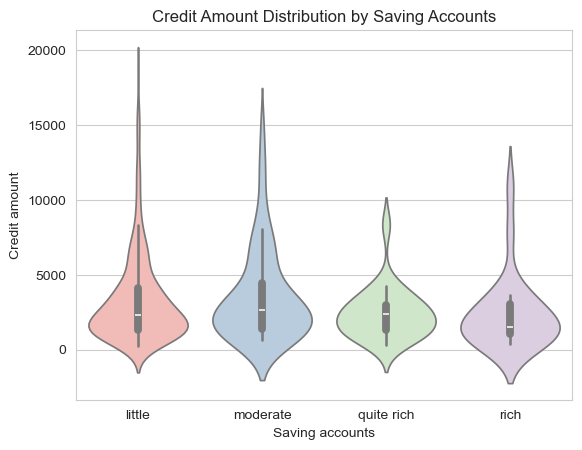

In [108]:
sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette="Pastel1")
plt.title("Credit Amount Distribution by Saving Accounts")
plt.show()

In [110]:
df["Risk"].value_counts(normalize=True)*100

good    55.747126
bad     44.252874
Name: Risk, dtype: float64

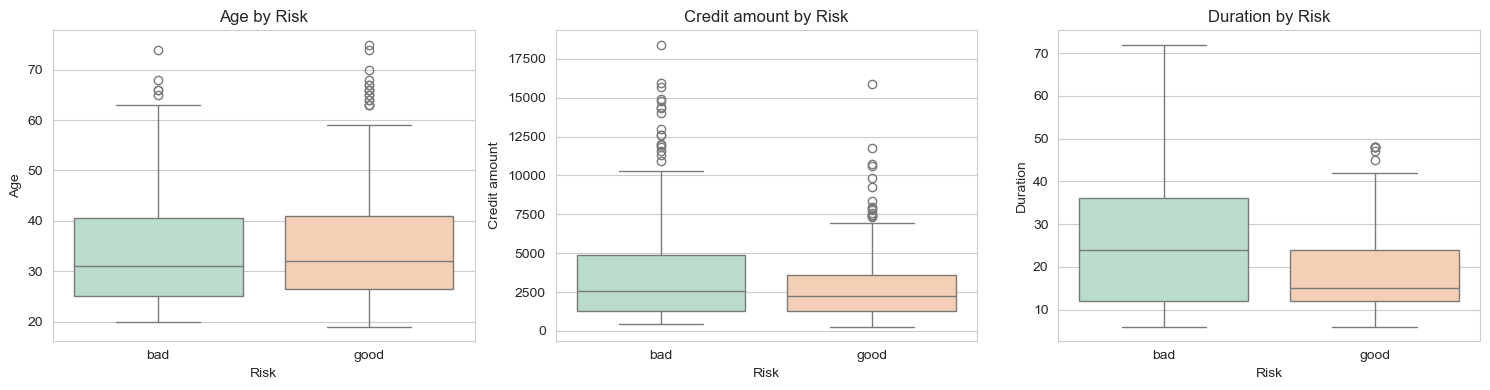

In [124]:
plt.figure(figsize=(15,4))
for i, col in enumerate(["Age", "Credit amount", "Duration"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=df,
        x="Risk",
        y=col,
        hue="Risk",
        palette="Pastel2",
        legend=False)
    plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()

In [126]:
df.groupby("Risk")[["Age","Credit amount","Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


In [128]:
categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

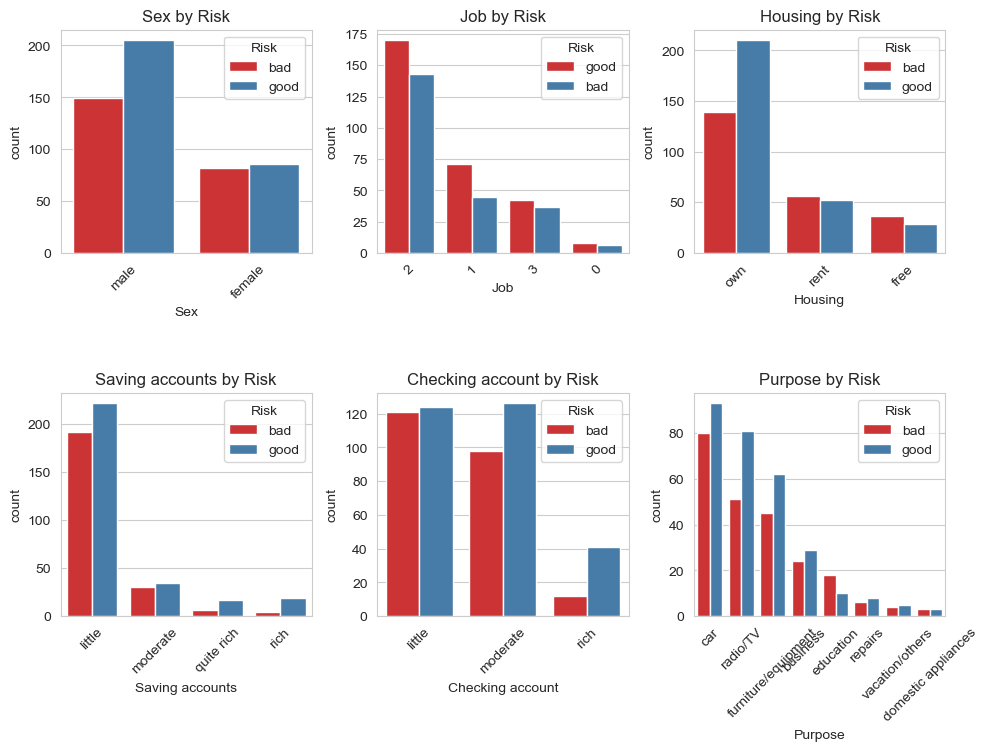

In [132]:
plt.figure(figsize=(10,10))
for i,col in enumerate(categorical_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(data=df,x=col,hue="Risk", palette="Set1", order=df[col].value_counts().index)
    plt.title(f"{col} by Risk")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [134]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [136]:
features=["Age","Sex","Job","Housing","Saving accounts","Checking account","Credit amount","Duration"]

In [138]:
target="Risk"

In [140]:
df_model=df[features+[target]].copy()

In [142]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [144]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [146]:
cat_cols=df_model.select_dtypes(include="object").columns.drop("Risk")

In [148]:
le_dict={}

In [150]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='object')

In [152]:
for col in cat_cols:
    le=LabelEncoder()
    df_model[col]=le.fit_transform(df_model[col])
    le_dict[col]=le
    joblib.dump(le, f"{col}_encoder.pkl")

In [154]:
le_target=LabelEncoder()

In [156]:
target

'Risk'

In [158]:
df_model[target]=le_target.fit_transform(df_model[target])

In [160]:
df_model[target].value_counts()

1    291
0    231
Name: Risk, dtype: int64

In [162]:
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [164]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


In [166]:
from sklearn.model_selection import train_test_split

In [168]:
X=df_model.drop(target,axis=1)

In [170]:
y=df_model[target]

In [172]:
X

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
0,22,0,2,1,0,1,5951,48
1,45,1,2,0,0,0,7882,42
2,53,1,2,0,0,0,4870,24
3,35,1,3,2,0,1,6948,36
4,28,1,3,1,0,1,5234,30
...,...,...,...,...,...,...,...,...
517,48,1,1,1,0,1,1743,24
518,30,1,3,1,0,0,3959,36
519,40,1,3,1,0,0,3857,30
520,23,1,2,0,0,0,1845,45


In [174]:
y

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int32

In [176]:
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2, stratify=y, random_state=1)

In [178]:
X_train.shape

(417, 8)

In [180]:
X_test.shape

(105, 8)

In [185]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [195]:
def train_model(model, param_grid, X_train, y_train, X_test, y_test):
    grid=GridSearchCV(model, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train,y_train)
    best_model=grid.best_estimator_
    y_pred=best_model.predict(X_test)
    acc=accuracy_score(y_test ,y_pred)
    return best_model, acc, grid.best_params_

In [207]:
dt=DecisionTreeClassifier(random_state=1, class_weight="balanced")
dt_param_grid={
    "max_depth":[3,5,7,10,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

In [209]:
best_dt,acc_dt, params_dt=train_model(dt,dt_param_grid,X_train,y_train,X_test,y_test)

In [211]:
print("Decision Tree Accuracy", acc_dt)

Decision Tree Accuracy 0.580952380952381


In [213]:
print("Best parameters", params_dt)

Best parameters {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [215]:
rf=RandomForestClassifier(random_state =1, class_weight="balanced", n_jobs=1)


In [217]:
rf_param_grid={
    "n_estimators":[100,200],
    "max_depth":[5,7,10, None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
}

In [221]:
best_rf, acc_rf, params_rf= train_model(rf, rf_param_grid, X_train, y_train, X_test, y_test)

In [223]:
print("Random Forest Accuracy", acc_rf)

Random Forest Accuracy 0.6190476190476191


In [225]:
print("Best params", params_rf)

Best params {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


In [229]:
et=ExtraTreesClassifier(random_state=1, class_weight="balanced", n_jobs=-1)

In [231]:
et_param_grid={
    "n_estimators":[100,200],
    "max_depth":[5,7,10, None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
}

In [233]:
best_et, acc_et, params_et =train_model(et, et_param_grid, X_train, y_train, X_test, y_test)

In [235]:
print("Extra trees accuracy", acc_et)

Extra trees accuracy 0.6476190476190476


In [237]:
print("Best params:", params_et)

Best params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [239]:
xgb = XGBClassifier(random_state=1, scale_pos_weight= (y_train ==0).sum()/(y_train==1).sum(), use_label_encoder= False, eval_metric="logloss")

In [243]:
xgb_param_grid={
    "n_estimators":[100,200],
    "max_depth":[3,5,7],
    "learning_rate":[0.01, 0.1, 0.2],
    "subsample":[0.7,1],
    "colsample_bytree":[0.7,1]
}


In [245]:
best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_param_grid, X_train, y_train, X_test, y_test)

D:\Users\leela\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [09:49:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [247]:
print("XGB accuracy", acc_xgb)

XGB accuracy 0.6761904761904762


In [249]:
print("Best params", params_xgb)

Best params {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1}


In [251]:
best_xgb.predict(X_test)

array([1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0])

In [253]:
joblib.dump(best_xgb, "XGBoost_model.pkl")

['XGBoost_model.pkl']

In [257]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')